**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


**Parameters for data preprocessing**

In [2]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000                                                             

### Filepaths MFCC ###
# Training
data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\lfcc_segment_outputs\\lfcc_tensors_train_set_with_delta'

# Development/Validation
dev_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\lfcc_segment_outputs\\lfcc_tensors_dev_set_with_delta'


**Preprocessing of training data** 

In [3]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    features_list.append(feature)  # Append the tensors
    labels_list.append(label) # Append the labels

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-4.2530e+02, -4.1924e+02, -3.9770e+02,  ...,  6.0272e+01,
          6.8002e+01,  2.5774e+01],
        [ 1.6841e+01,  2.4703e+01,  4.3698e+01,  ..., -3.0947e+01,
          3.3626e+01,  8.9386e+01],
        [ 1.6329e+01,  2.2457e+01,  2.8052e+01,  ..., -8.7384e+00,
         -5.5001e+00, -8.3772e+00],
        ...,
        [ 1.5694e-01,  1.5694e-01,  1.5694e-01,  ...,  7.2835e-01,
          7.2835e-01,  7.2835e-01],
        [-4.2251e-01, -4.2251e-01, -4.2251e-01,  ...,  1.1511e+00,
          1.1511e+00,  1.1511e+00],
        [-4.1666e-01, -4.1666e-01, -4.1666e-01,  ...,  1.4123e-02,
          1.4123e-02,  1.4123e-02]])
Example of the features tensor([[-2.8503e+02, -2.9261e+02, -3.0101e+02,  ..., -1.7056e+02,
         -1.3316e+00,  4.3546e+01],
        [ 6.4047e+01,  6.1352e+01,  5.7275e+01,  ...,  1.0076e+02,
          1.2351e+02,  1.2853e+02],
        [ 2.7008e+01,  3.0462e+01,  3.2180e+01,  ...,  4.3480e+01,
          4.7021e+01,  4.5388e+01],
        ...

**Dataset inspection**

In [4]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([120, 126])
First sample values:
 tensor([[-4.2530e+02, -4.1924e+02, -3.9770e+02,  ...,  6.0272e+01,
          6.8002e+01,  2.5774e+01],
        [ 1.6841e+01,  2.4703e+01,  4.3698e+01,  ..., -3.0947e+01,
          3.3626e+01,  8.9386e+01],
        [ 1.6329e+01,  2.2457e+01,  2.8052e+01,  ..., -8.7384e+00,
         -5.5001e+00, -8.3772e+00],
        ...,
        [ 1.5694e-01,  1.5694e-01,  1.5694e-01,  ...,  7.2835e-01,
          7.2835e-01,  7.2835e-01],
        [-4.2251e-01, -4.2251e-01, -4.2251e-01,  ...,  1.1511e+00,
          1.1511e+00,  1.1511e+00],
        [-4.1666e-01, -4.1666e-01, -4.1666e-01,  ...,  1.4123e-02,
          1.4123e-02,  1.4123e-02]])
Sample Labels:
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 

**Testing the Data Loader**

In [5]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

120
torch.Size([25380, 120, 126])
Batch features shape: torch.Size([64, 120, 126])


**Preprocessing and loading the Development/Validation Set**

In [6]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[-3.4720e+02, -2.3046e+02, -1.0462e+02,  ...,  1.1186e+02,
          2.6001e+01,  8.7326e+00],
        [ 3.2223e+01,  1.2686e+02,  2.0104e+02,  ...,  1.2657e+02,
          2.1654e+02,  1.7764e+02],
        [ 2.9802e+01,  1.3691e+01, -1.7798e+01,  ...,  2.6378e+01,
         -2.6602e+01, -1.9582e+01],
        ...,
        [ 4.4822e-02,  4.4822e-02,  4.4822e-02,  ..., -2.4546e-01,
         -2.4546e-01, -2.4546e-01],
        [ 2.2051e-01,  2.2051e-01,  2.2051e-01,  ...,  1.9237e-02,
          1.9237e-02,  1.9237e-02],
        [ 2.7726e-01,  2.7726e-01,  2.7726e-01,  ..., -1.9239e-01,
         -1.9239e-01, -1.9239e-01]])
Example of the features tensor([[-3.6207e+02, -3.6978e+02, -3.7621e+02,  ...,  1.1933e+02,
          1.0973e+02,  9.4715e+01],
        [ 3.6911e+01,  2.8239e+01,  1.9419e+01,  ..., -7.6180e+01,
         -4.8228e+01, -1.2535e+01],
        [ 3.1199e+01,  2.7093e+01,  1.9052e+01,  ..., -5.6702e+01,
         -4.7041e+01, -4.1919e+01],
        ...

**Testing the Processed Dataloaders and Label Distribution**

In [7]:
print("Training features shape",features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([64, 120, 126]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Training labels shape torch.Size([64])
Development features shape: torch.Size([24844, 120, 126]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Development labels shape: torch.Size([24844])
Training label distribution: tensor([61,  3])
Validation label distribution: tensor([22296,  2548])


**Hyperparemeters**

In [15]:
hidden_dim = 256  # Number of neurons in the hidden layer
dropout_prob = 0.3  # Dropout probability

**Neural Network Model**

In [16]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob):
        super(SpoofDetectionModel, self).__init__()

        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=120, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)

        self.dropout = nn.Dropout(dropout_prob)

        # Fully connected layers (fc1 will be initialized dynamically)
        self.fc1 = None
        self.hidden_dim = hidden_dim
        self.fc2 = None
        self.fc3 = nn.Linear(64, 1)

    def init_weights(self, m):
        if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
            torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool(x)

        x = torch.relu(self.conv3(x))
        x = self.bn3(x)
        x = self.pool(x)

        x = self.dropout(x)
        x = x.view(x.size(0), -1)

        # Dynamically initialize fc1 and fc2 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), self.hidden_dim).to(x.device)
            self.fc1.apply(self.init_weights)
        if self.fc2 is None:
            self.fc2 = nn.Linear(self.hidden_dim, 64).to(x.device)
            self.fc2.apply(self.init_weights)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

**Initializing the model**

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

print(device)

cuda


**Calculate the weights proportion for weighted loss**

In [18]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.74% | Bonafide: 10.26%
Weight of class 0 (spoof): tensor(0.5571)
Weight of class 1 (bonafide): tensor(4.8752)
Weight tensor to be passed to the Loss Function tensor(4.8752)


C:\Users\fnobrega\AppData\Local\Temp\ipykernel_10500\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [19]:
criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [20]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 5  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



**Training Loop**

In [22]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
# Training loop
num_epochs = 100

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for LFCC -> old code, possibly for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    model.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}% | "
          f"Val Threshold: {threshold_val:.2f}%")

    # Learning rate scheduling
    scheduler.step(avg_loss_val)


    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        best_threshold = threshold_val  # Save the threshold for best EER
        torch.save(model.state_dict(), 'lfcc_deep_best_model.pth')
    # Save the threshold to a file
        with open('lfcc_deep_best_threshold.txt', 'w') as f:
            f.write(str(best_threshold))
            f.write(str(best_eer))
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            print("Early stopping triggered (EER did not improve).")
            break

Epoch [1/100] | Train Loss: 0.2092, Acc: 97.17% | Val Loss: 0.1014, Acc: 98.60% | Val EER: 0.98% | Val Threshold: 0.38%
Epoch [2/100] | Train Loss: 0.0955, Acc: 98.75% | Val Loss: 0.0507, Acc: 99.32% | Val EER: 0.71% | Val Threshold: -0.06%
Epoch [3/100] | Train Loss: 0.0536, Acc: 99.41% | Val Loss: 0.0301, Acc: 99.67% | Val EER: 0.45% | Val Threshold: -0.38%
Epoch [4/100] | Train Loss: 0.0386, Acc: 99.51% | Val Loss: 0.0219, Acc: 99.73% | Val EER: 0.35% | Val Threshold: -0.37%
Epoch [5/100] | Train Loss: 0.0269, Acc: 99.66% | Val Loss: 0.0174, Acc: 99.79% | Val EER: 0.24% | Val Threshold: -0.50%
Epoch [6/100] | Train Loss: 0.0216, Acc: 99.73% | Val Loss: 0.0127, Acc: 99.80% | Val EER: 0.21% | Val Threshold: -0.18%
Epoch [7/100] | Train Loss: 0.0167, Acc: 99.81% | Val Loss: 0.0124, Acc: 99.76% | Val EER: 0.24% | Val Threshold: -0.18%
EER not improved. Patience counter: 1/5
Epoch [8/100] | Train Loss: 0.0130, Acc: 99.85% | Val Loss: 0.0103, Acc: 99.84% | Val EER: 0.17% | Val Threshold: 

**Plotting the results**

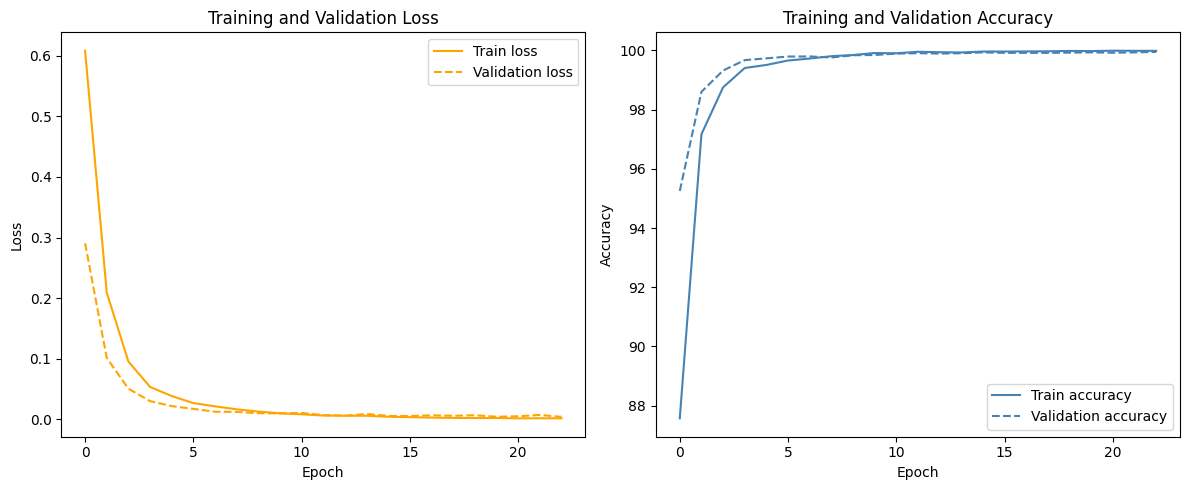

In [23]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model**

In [ ]:
# Save weights only
torch.save(model.state_dict(), 'lfcc_with_delta_v3_updated_model_deepfake_audio_detection_model.pth')

# Save the full model (architecture + weights)
torch.save(model, 'lfcc_with_delta_v2_updated_model_deepfake_audio_detection_model_full.pt')

**Prepare Evaluation Dataset**

In [24]:
# Evaluation
eval_data_dir = 'D:\\Felipe\\Team Lab\\teamlab-phonetics\\feature_extraction\\lfcc_segment_outputs\\lfcc_tensors_eval_set_with_delta'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(eval_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(eval_data_dir, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([[-3.1719e+02, -1.8039e+02, -6.8076e+01,  ..., -4.5134e+01,
         -3.8520e+01, -1.7389e+01],
        [ 8.4354e+01,  1.6613e+02,  2.0741e+02,  ...,  2.5119e+02,
          2.3634e+02,  2.3194e+02],
        [ 4.2919e+01,  3.2076e+01,  1.4553e+01,  ..., -4.7070e+00,
         -1.9970e+00, -8.4831e-02],
        ...,
        [ 1.7571e-02,  1.7571e-02,  1.7571e-02,  ...,  2.3086e-01,
          2.3086e-01,  2.3086e-01],
        [-4.9345e-01, -4.9345e-01, -4.9345e-01,  ...,  2.9802e-01,
          2.9802e-01,  2.9802e-01],
        [-1.0044e-01, -1.0044e-01, -1.0044e-01,  ...,  5.3810e-02,
          5.3810e-02,  5.3810e-02]])
Example of the features tensor([[-3.3888e+02, -3.7314e+02, -2.9060e+02,  ..., -3.8714e+02,
         -3.9049e+02, -3.9146e+02],
        [ 3.6489e+01,  3.1510e+01,  9.5408e+01,  ...,  2.2135e+01,
          1.7525e+01,  1.6173e+01],
        [ 1.3734e+01,  1.6058e+01,  4.1746e+01,  ...,  2.1536e+01,
          1.7273e+01,  1.5978e+01],
        ...


Evaluation Set:
Loss: 2.7779 | Accuracy: 53.29%
EER: 11.16% | Logit Threshold: 8.6428 | Prob Threshold: 0.9998
F1 Score: 0.6216
Precision: 0.4781
Recall: 0.8884
Predictions: [1]: 13668 | [0]: 57569


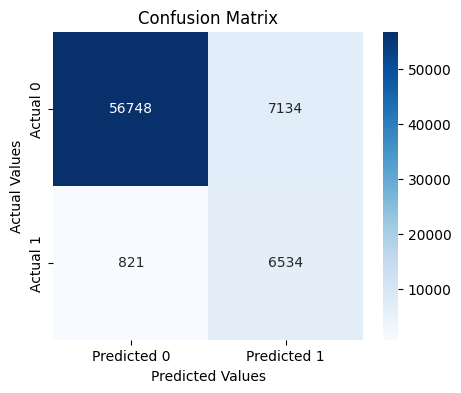

In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            total_loss += loss.item()
            predicted = (outputs > 0).float()
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Convert to NumPy arrays
    all_labels = np.array(all_labels)
    all_scores = np.array(all_scores)
    
    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(all_labels, all_scores)
    prob_threshold = expit(threshold)
    preds = (all_scores >= threshold).astype(int)
    
    # Calculate precision and recall
    precision = precision_score(all_labels, preds)
    recall = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)

    # Print results with precision and recall
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Values')
    plt.ylabel('Actual Values')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_on_eval_set(model, eval_dataLoader)